In [ ]:
import sys
import os
from dotenv import load_dotenv
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import jaccard

import metric_utils
# if notebook is in PRIN/notebooks, parent() is PRIN
#project_root = Path.cwd().resolve().parent
#sys.path.insert(0, str(project_root))
#print("Added to sys.path:", project_root)

import json
from constants import Annotations, AnnotatedReport
import time
from IPython.display import clear_output

from huggingface_hub import login

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from transformers import AutoTokenizer, DefaultDataCollator
from datasets import load_dataset, Dataset, DatasetDict

from model_utils import create_label_to_id_map

from train_utils import get_device, add_nan_flag_to_df, create_list_of_annotated_reports, create_hugging_face_dataset, add_target_columns_to_dataset, get_normalization_stats
from classifiers import ReportExtractor
from tqdm import tqdm
import sklearn.metrics as metrics
import numpy as np
from pprint import pprint

from utils.splitta_dati import Y_train

In [ ]:
############
# Parameters
############
# Data parameters
TRAIN_FILE_NAME = "train_split.csv"
VALIDATION_FILE_NAME = "validation_split.csv"
TEST_FILE_NAME = "test_split.csv"

In [ ]:
plt.style.use('ggplot')

In [6]:
base_dir = Path.cwd().parent

In [7]:
# Set device
device = get_device()
print(f'{device = }')

torch.cuda.is_available() = True
torch.cuda.device_count() = 1
NVIDIA GeForce RTX 5070
device = device(type='cuda')


In [8]:
model = ReportExtractor.from_pretrained(base_dir / "saved_models" / "report_extractor", device=device)
model.to(device)
model.eval()
tokenizer = AutoTokenizer.from_pretrained(base_dir / "saved_models" / "report_extractor")

Some weights of BertModel were not initialized from the model checkpoint at IVN-RIN/bioBIT and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:
###########
# Load data
###########
file_names = {
    'train': TRAIN_FILE_NAME,
    'validation': VALIDATION_FILE_NAME,
    'test': TEST_FILE_NAME
}
paths = {split: base_dir / "data" / file_name
         for split, file_name in file_names.items()}
data = {split: pd.read_csv(path) for split, path in paths.items()}
train_data, validation_data, test_data = data['train'], data['validation'], data['test']
# Log
print(f"{len(train_data) = }")
print(f"{len(validation_data) = }")
print(f"{len(test_data) = }")
# Create nan-flag columns
for split, df in data.items():
    add_nan_flag_to_df(df)
# Create lists of Annotated reports
annotated_reports =  {split: create_list_of_annotated_reports(data[split]) for split in file_names}

len(train_data) = 167
len(validation_data) = 46
len(test_data) = 56


In [10]:
# Check the maximum number of tokens for each report
print('model context length:', model.encoder.config.max_position_embeddings)
for split in annotated_reports:
    print(f'{split}: {len(annotated_reports[split])} reports')
    max_n_tokens = 0
    del_list = []
    for i, report in enumerate(annotated_reports[split]):
        x = tokenizer(report.report_text, return_tensors='pt')['input_ids'].shape[1]
        max_n_tokens = max(max_n_tokens, x)
        if x > model.encoder.config.max_position_embeddings:
            del_list.append(i)
    print(del_list)
    print(f'{max_n_tokens = }')
    # Delete long reports
    for i in del_list[::-1]:
        annotated_reports[split].pop(i)
    print(f'After deletion: {len(annotated_reports[split])} reports')

Token indices sequence length is longer than the specified maximum sequence length for this model (1427 > 512). Running this sequence through the model will result in indexing errors


model context length: 512
train: 167 reports
[0, 2, 10, 25, 30, 33, 38, 77, 91, 93, 97, 98, 99, 115, 116, 127, 130, 134, 148, 149, 150, 158, 161, 162, 163, 164, 166]
max_n_tokens = 1427
After deletion: 140 reports
validation: 46 reports
[7, 11, 23, 33, 34, 37, 38, 42, 44]
max_n_tokens = 1008
After deletion: 37 reports
test: 56 reports
[2, 6, 16, 23, 26, 28, 33, 37, 42, 43, 45, 47]
max_n_tokens = 861
After deletion: 44 reports


In [11]:
##############################
# Create Hugging Face Datasets
##############################
dataset = DatasetDict({
    split: create_hugging_face_dataset(annotated_reports[split])
    for split in annotated_reports
})
# Tokenize text and set format to torch
def tokenize_function(examples):
    return tokenizer(examples['text'], padding="longest", max_length=model.encoder.config.max_position_embeddings)
dataset = dataset.map(tokenize_function, batched=True)
cols_to_remove = [col for col in ["token_type_ids"] if col in dataset['validation'].column_names]
dataset = dataset.remove_columns(cols_to_remove)
dataset.set_format('torch')
# Add annotation fields to the dataset
for split, reports in annotated_reports.items():
    dataset[split] = add_target_columns_to_dataset(dataset=dataset[split],
                                                   annotated_reports=reports,
                                                   label_to_id_map=model.label_to_id_map,
                                                   classification_columns=model.classification_fields,
                                                   binary_classification_columns=model.binary_classification_fields,
                                                   multiple_choice_columns=model.multiple_choice_fields,
                                                   regression_columns=model.regression_fields,
                                                   normalization_stats=model.normalization_stats)


Map:   0%|          | 0/140 [00:00<?, ? examples/s]

Map:   0%|          | 0/37 [00:00<?, ? examples/s]

Map:   0%|          | 0/44 [00:00<?, ? examples/s]

In [12]:
dataset.set_format(
    type="torch",
)
loader = DataLoader(dataset["test"], batch_size=16, shuffle=False)
model.eval()
batches_results = []
with torch.no_grad():
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        model_output = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        reworked_output = model.rework_output(model_output)

        batches_results.append(reworked_output)

    predictions = {
        field: np.concatenate([r[field] for r in batches_results])
        for field in model.all_fields()
    }

In [17]:
campo = 'posizione'
dataset.set_format('numpy')

pred_prob = predictions[campo][:5]
y_true = dataset['test'][campo][:5]


print(pred_prob)
print(y_true)

[[0.46824723 0.5759687  0.51125085 0.41332936]
 [0.44939747 0.5781334  0.53615534 0.4330645 ]
 [0.45269975 0.5627926  0.5225839  0.4049387 ]
 [0.44723678 0.5841532  0.5345772  0.40184277]
 [0.44057712 0.5377207  0.530565   0.45874593]]
[[1 1 0 0]
 [0 1 1 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 1 0 0]]


In [19]:
y_pred = (pred_prob > 0.5).astype(int)
print(y_pred)

[[0 1 1 0]
 [0 1 1 0]
 [0 1 1 0]
 [0 1 1 0]
 [0 1 1 0]]


In [69]:
metrics.multilabel_confusion_matrix(y_true, y_pred)[0]

array([[1, 0],
       [4, 0]])

In [50]:
(0.66+0.4)/4

0.265

In [33]:
5/12

0.4166666666666667

In [80]:
def metrics_multilabel(y_true: np.ndarray, pred_prob: np.ndarray,
                       id_to_label_dict: dict[int, str],
                       thresholds: float | list[float] = 0.5,
                       plot=True,
                       field_name=None):

    # --- Predizioni ---
    if type(thresholds) is list:
        thresholds = np.array(thresholds)
    y_pred = (pred_prob > thresholds).astype(int)

    labels = list(id_to_label_dict.values())
    result = {
        'exact_match_acc': (y_pred == y_true).all(axis=1).mean(),
        'hamming': metrics.hamming_loss(y_true, y_pred),  # Lower is better
        'f1_micro': metrics.f1_score(y_true, y_pred, average="micro", zero_division=0.0),
        'f1_macro': metrics.f1_score(y_true, y_pred, average="macro", zero_division=0.0),
        'f1_weighted': metrics.f1_score(y_true, y_pred, average="weighted", zero_division=0.0),
        'f1_samples': metrics.f1_score(y_true, y_pred, average="samples", zero_division=0.0),
        'jaccard_micro': metrics.jaccard_score(y_true, y_pred, average="micro", zero_division=0.0),
        'jaccard_macro': metrics.jaccard_score(y_true, y_pred, average="macro", zero_division=0.0),
        'jaccard_weighted': metrics.jaccard_score(y_true, y_pred, average="weighted", zero_division=0.0),
        'jaccard_samples': metrics.jaccard_score(y_true, y_pred, average="samples", zero_division=0.0)
    }

    # --- Plot ---
    if plot:
        confusion_matrices = metrics.multilabel_confusion_matrix(y_true, y_pred)
        fig, axes = plt.subplots(1, len(labels), figsize=(5*len(labels), 5))

        if field_name is not None:
            fig.suptitle(field_name, fontsize="xx-large")

        for i, m in enumerate(confusion_matrices):
            metrics.ConfusionMatrixDisplay(confusion_matrix=m).plot(ax=axes[i])
            axes[i].grid(False)
            axes[i].set_title(labels[i])
        plt.show()

    return result


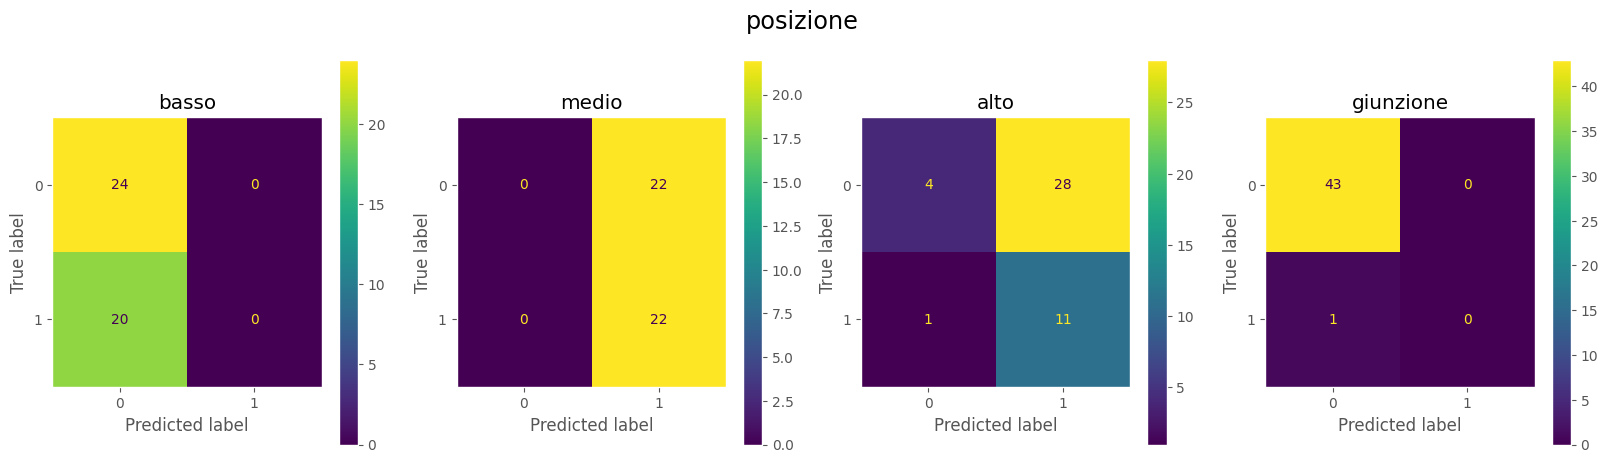

In [81]:
report = metrics_multilabel(dataset['test'][campo][:], predictions[campo],
                            id_to_label_dict=model.label_to_id_map[campo]['id_to_label'],
                            field_name=campo)

In [75]:
pprint(report)

{'exact_match_acc': np.float64(0.18181818181818182),
 'f1_macro': 0.27450980392156865,
 'f1_micro': 0.4782608695652174,
 'f1_samples': 0.428030303030303,
 'f1_weighted': 0.3607843137254902,
 'hamming': 0.4090909090909091,
 'jaccard_macro': 0.19375,
 'jaccard_micro': 0.3142857142857143,
 'jaccard_samples': 0.35984848484848486,
 'jaccard_weighted': 0.26}
